In [1]:
#Feature Space Formulation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Visual aesthetics
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load cleaned dataset
file_path = 'Cleaned_DataCo_Logistics.csv'
df = pd.read_csv(file_path)
print(f'Cleaned Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns\n')

# Select predictive features available prior to dispatch
feature_cols = [
    'Days for shipment (scheduled)',
    'Sales per customer',
    'Order Item Product Price',
    'Order Item Quantity',
    'Dispatch_Day_Of_Week',
    'Is_Weekend_Dispatch',
    'Shipping Mode',
    'Order Region',
]

target_col = 'Days for shipping (real)'

X = df[feature_cols].copy()
y = df[target_col].copy()

print(f'Features selected: {feature_cols}')
print(f'Target variable:   {target_col}')

Cleaned Dataset Loaded: 180519 rows, 59 columns

Features selected: ['Days for shipment (scheduled)', 'Sales per customer', 'Order Item Product Price', 'Order Item Quantity', 'Dispatch_Day_Of_Week', 'Is_Weekend_Dispatch', 'Shipping Mode', 'Order Region']
Target variable:   Days for shipping (real)


In [2]:
# One-Hot Encoding & Train-Test Splitting
# Convert categorical features to numeric vectors
X_encoded = pd.get_dummies(X, drop_first=True)

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

print(f'Training Set Size: {X_train.shape[0]} records')
print(f'Testing Set Size:  {X_test.shape[0]} records')
print(f'Total Dimensionality: {X_train.shape[1]} input features')

Training Set Size: 144415 records
Testing Set Size:  36104 records
Total Dimensionality: 31 input features


In [3]:
# CELL 3: Model Training & Benchmarking
models = {
    'Linear Regression (Baseline)': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(
        max_depth=10, random_state=42
    ),
    'Random Forest Regressor (Ensemble)': RandomForestRegressor(
        n_estimators=100, max_depth=12, n_jobs=-1, random_state=42
    ),
}

results = []

for name, model in models.items():
  print(f'Training {name}...')
  model.fit(X_train, y_train)

  # Inference on holdout set
  y_pred = model.predict(X_test)

  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2 = r2_score(y_test, y_pred)

  results.append({
      'Model Architecture': name,
      'MAE (Days)': round(mae, 4),
      'RMSE (Days)': round(rmse, 4),
      'R² Score': round(r2, 4),
  })

# Collate results into a benchmark table
results_df = pd.DataFrame(results)
print('\n' + '=' * 65)
print('--- MODEL BENCHMARK PERFORMANCE TABLE ---')
print('=' * 65)
print(results_df.to_string(index=False))

Training Linear Regression (Baseline)...
Training Decision Tree Regressor...
Training Random Forest Regressor (Ensemble)...

--- MODEL BENCHMARK PERFORMANCE TABLE ---
                Model Architecture  MAE (Days)  RMSE (Days)  R² Score
      Linear Regression (Baseline)      0.9845       1.2662    0.3918
           Decision Tree Regressor      0.9866       1.2701    0.3880
Random Forest Regressor (Ensemble)      0.9827       1.2652    0.3927


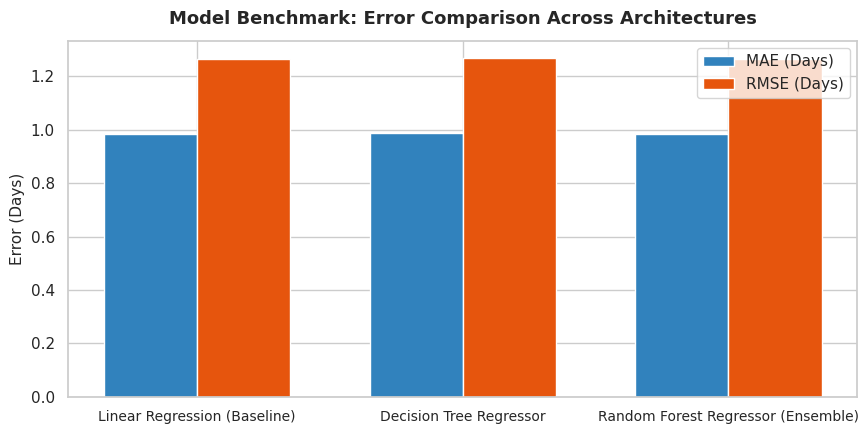

In [4]:
# CELL 4: Chart 1 - Benchmark Error Comparison Bar Chart
plt.figure(figsize=(9, 4.5))
x_pos = np.arange(len(results_df))
bar_width = 0.35

plt.bar(
    x_pos - bar_width / 2,
    results_df['MAE (Days)'],
    width=bar_width,
    label='MAE (Days)',
    color='#3182bd',
)
plt.bar(
    x_pos + bar_width / 2,
    results_df['RMSE (Days)'],
    width=bar_width,
    label='RMSE (Days)',
    color='#e6550d',
)

plt.xticks(x_pos, results_df['Model Architecture'], fontsize=10)
plt.ylabel('Error (Days)', fontsize=11)
plt.title(
    'Model Benchmark: Error Comparison Across Architectures',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

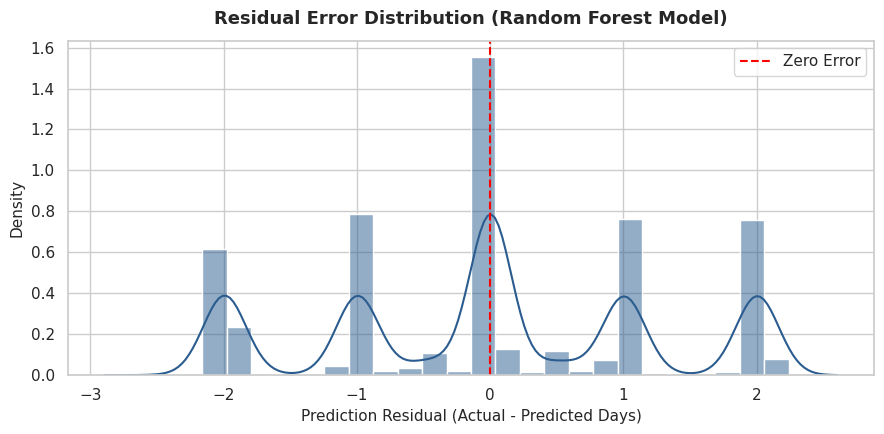

In [5]:
# CELL 5: Chart 2 - Residual Error Distribution
best_model = models['Random Forest Regressor (Ensemble)']
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

plt.figure(figsize=(9, 4.5))
sns.histplot(
    residuals,
    kde=True,
    color='#2b5c8f',
    bins=30,
    stat='density',
    edgecolor='white',
)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')

plt.title(
    'Residual Error Distribution (Random Forest Model)',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Prediction Residual (Actual - Predicted Days)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

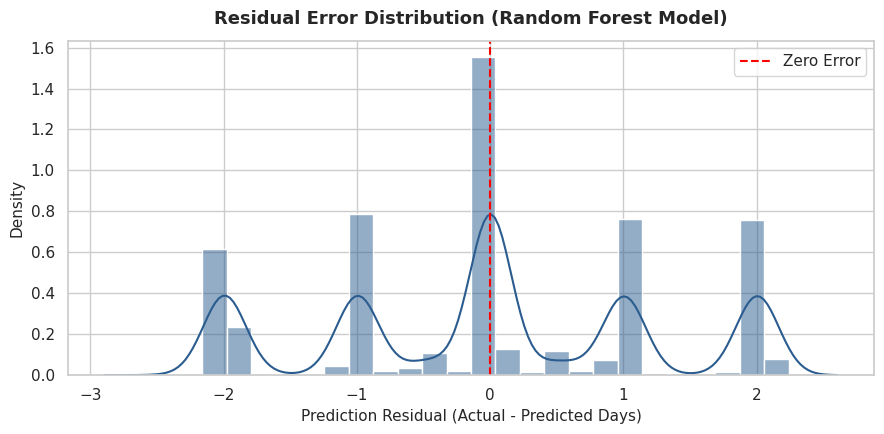

In [6]:
# CELL 5: Chart 2 - Residual Error Distribution
best_model = models['Random Forest Regressor (Ensemble)']
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

plt.figure(figsize=(9, 4.5))
sns.histplot(
    residuals,
    kde=True,
    color='#2b5c8f',
    bins=30,
    stat='density',
    edgecolor='white',
)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error')

plt.title(
    'Residual Error Distribution (Random Forest Model)',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Prediction Residual (Actual - Predicted Days)', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

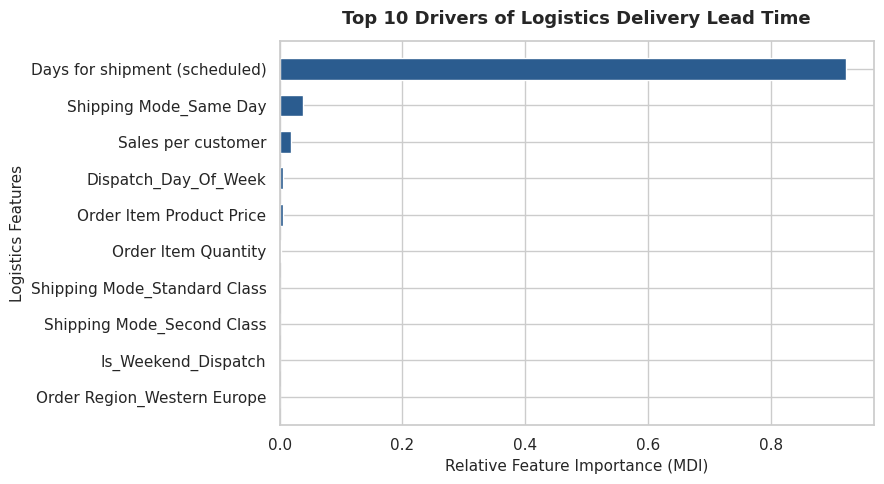

In [7]:
# CELL 6: Chart 3 - Top 10 Feature Importances
importances = best_model.feature_importances_
top_indices = np.argsort(importances)[-10:]
top_features = [X_encoded.columns[i] for i in top_indices]
top_importance_vals = importances[top_indices]

plt.figure(figsize=(9, 5))
plt.barh(top_features, top_importance_vals, color='#2b5c8f', height=0.6)

plt.title(
    'Top 10 Drivers of Logistics Delivery Lead Time',
    fontsize=13,
    fontweight='bold',
    pad=12,
)
plt.xlabel('Relative Feature Importance (MDI)', fontsize=11)
plt.ylabel('Logistics Features', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# CELL 7: Interactive Prediction & Optimization Engine
def predict_shipment_performance(
    shipping_mode='Standard Class',
    order_region='South Asia',
    scheduled_days=4,
    sales_amount=150.0,
    product_price=50.0,
    quantity=3,
    dispatch_day_of_week=0,  # 0=Monday, 6=Sunday
):
  """Accepts custom order parameters and outputs predicted transit days,

  SLA delay risk (0/1), and an automated optimization recommendation.
  """
  # Construct single-row DataFrame matching training input format
  input_data = pd.DataFrame([{
      'Days for shipment (scheduled)': scheduled_days,
      'Sales per customer': sales_amount,
      'Order Item Product Price': product_price,
      'Order Item Quantity': quantity,
      'Dispatch_Day_Of_Week': dispatch_day_of_week,
      'Is_Weekend_Dispatch': 1 if dispatch_day_of_week in [5, 6] else 0,
      'Shipping Mode': shipping_mode,
      'Order Region': order_region,
  }])

  # One-hot encode and reindex to align with training columns
  input_encoded = pd.get_dummies(input_data)
  input_aligned = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)

  # Predict transit duration using the trained Random Forest model
  pred_days = best_model.predict(input_aligned)[0]

  # Evaluate delay risk
  delay_variance = pred_days - scheduled_days
  is_late_risk = 1 if pred_days > scheduled_days else 0

  # Print structured operational breakdown
  print('\n' + '=' * 65)
  print('--- LOGISTICS PREDICTION & OPTIMIZATION INFERENCE ---')
  print('=' * 65)
  print('Input Order Configuration:')
  print(f'  • Shipping Mode:          {shipping_mode}')
  print(f'  • Destination Region:     {order_region}')
  print(f'  • Scheduled SLA Target:   {scheduled_days} Days')
  print(
      f'  • Dispatch Timing:        Weekday {dispatch_day_of_week}'
      f" {'(Weekend)' if dispatch_day_of_week in [5, 6] else '(Weekday)'}"
  )
  print('-' * 65)
  print('Model Predictions:')
  print(f'  ► Predicted Actual Days:  {pred_days:.2f} Days')
  print(f'  ► Predicted SLA Variance: {delay_variance:+.2f} Days')

  if is_late_risk == 1:
    buffer_needed = int(np.ceil(delay_variance))
    print(
        f'  ► Delay Risk Flag:        LATE RISK DETECTED (Late_delivery_risk = 1)'
    )
    print(
        f'  ► Optimization Action:    UPGRADE CARRIER TIER OR ADD'
        f' +{buffer_needed} DAY(S) BUFFER'
    )
  else:
    print(
        f'  ► Delay Risk Flag:        ON-TIME / ADVANCE (Late_delivery_risk = 0)'
    )
    print(
        f'  ► Optimization Action:    SCHEDULE CONFIRMED (No Intervention'
        ' Needed)'
    )
  print('=' * 65)

In [9]:
# CELL 8: Interactive Test Execution

# Scenario 1: Standard Class shipment with an unrealistic 2-day scheduled window
print('[RUNNING SCENARIO 1: High Risk Case]')
predict_shipment_performance(
    shipping_mode='Standard Class',
    order_region='South Asia',
    scheduled_days=2,
    sales_amount=220.0,
    product_price=110.0,
    quantity=2,
    dispatch_day_of_week=5,  # Saturday dispatch
)

# Scenario 2: Same Day delivery mode with realistic SLA
print('\n[RUNNING SCENARIO 2: Low Risk Premium Case]')
predict_shipment_performance(
    shipping_mode='Same Day',
    order_region='Western Europe',
    scheduled_days=1,
    sales_amount=350.0,
    product_price=350.0,
    quantity=1,
    dispatch_day_of_week=1,  # Tuesday dispatch
)

[RUNNING SCENARIO 1: High Risk Case]

--- LOGISTICS PREDICTION & OPTIMIZATION INFERENCE ---
Input Order Configuration:
  • Shipping Mode:          Standard Class
  • Destination Region:     South Asia
  • Scheduled SLA Target:   2 Days
  • Dispatch Timing:        Weekday 5 (Weekend)
-----------------------------------------------------------------
Model Predictions:
  ► Predicted Actual Days:  3.99 Days
  ► Predicted SLA Variance: +1.99 Days
  ► Delay Risk Flag:        LATE RISK DETECTED (Late_delivery_risk = 1)
  ► Optimization Action:    UPGRADE CARRIER TIER OR ADD +2 DAY(S) BUFFER

[RUNNING SCENARIO 2: Low Risk Premium Case]

--- LOGISTICS PREDICTION & OPTIMIZATION INFERENCE ---
Input Order Configuration:
  • Shipping Mode:          Same Day
  • Destination Region:     Western Europe
  • Scheduled SLA Target:   1 Days
  • Dispatch Timing:        Weekday 1 (Weekday)
-----------------------------------------------------------------
Model Predictions:
  ► Predicted Actual Days:  1.31 D